# \# Anomaly Detection
## -> DBSCAN
## -> Isolation Forest
## -> LOF (local outlier factor)
---------------------------------------

## <i>1> DBSCAN for anomaly detection

In [2]:
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

In [14]:
X, y = make_moons(
    n_samples = 500,
    noise=0.1,
    random_state = 42
)

In [15]:
# scale 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

<Axes: >

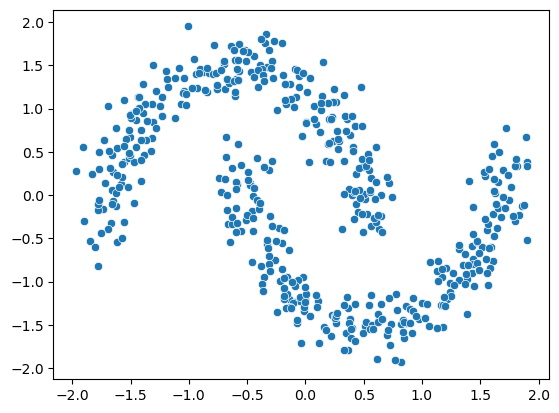

In [16]:
# visualize
sns.scatterplot(x = X_scaled[:,0], y=X_scaled[:,1])

<Axes: >

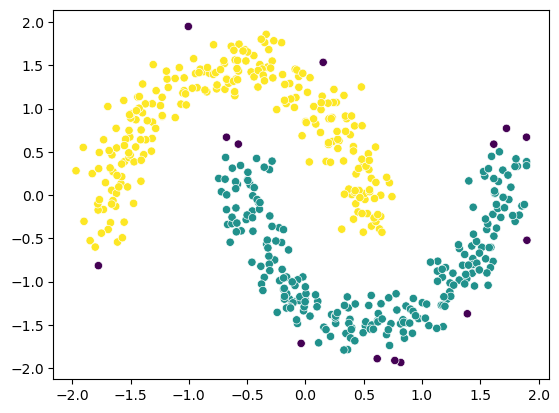

In [22]:
# DBSCAN
dbscan = DBSCAN(
    eps = 0.18,
    min_samples = 5
)

labels = dbscan.fit_predict(X_scaled)

sns.scatterplot(x=X_scaled[:,0], y = X_scaled[:,1], c = labels)

## 2> Isolation Forest

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [38]:
df = pd.read_csv("thyroid_dataset.csv")

In [39]:
X = df.drop("Outlier_label", axis=1)
y = df["Outlier_label"]

In [40]:
# scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [52]:
from sklearn.ensemble import IsolationForest

clf = IsolationForest(
    n_estimators = 200,
    contamination="auto", # auto if dont know the % of outlier
)

labels = clf.fit_predict(X_scaled)
labels

array([ 1,  1, -1, ...,  1,  1,  1], shape=(6916,))

In [53]:
# visualize
from sklearn.decomposition import PCA

pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X_scaled)

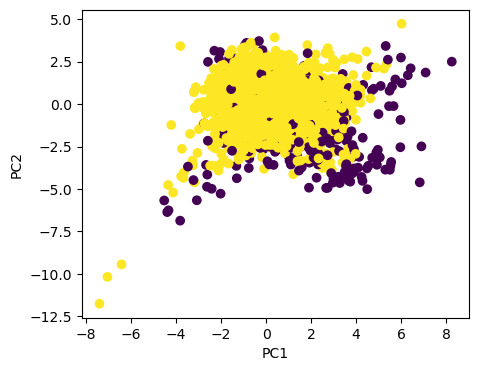

In [54]:
plt.figure(figsize=(5,4))

plt.scatter(X_pca[:,0], X_pca[:,1], c= labels)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [55]:
import numpy as np
n_outliers = np.sum(labels == -1)
n_normal = np.sum(labels == 1)

print("outliers : ", n_outliers)
print("normal : ", n_normal)

outliers :  264
normal :  6652


## 3> LOF for Anomalies

In [57]:
from sklearn.neighbors import LocalOutlierFactor

In [64]:
neighs = LocalOutlierFactor(contamination=0.036)
labels = neighs.fit_predict(X_scaled)

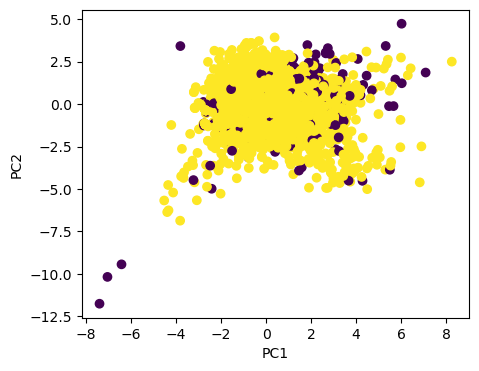

In [65]:
# visualize
from sklearn.decomposition import PCA

pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(5,4))

plt.scatter(X_pca[:,0], X_pca[:,1], c= labels)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [66]:
import numpy as np
n_outliers = np.sum(labels == -1)
n_normal = np.sum(labels == 1)

print("outliers : ", n_outliers)
print("normal : ", n_normal)

outliers :  249
normal :  6667
